# IPCA vs GIPCA: Welch & Goyal Macro Predictors

Compare four estimators on the same US stock return dataset:

| Model | Estimator | Predictive signal |
|-------|-----------|-------------------|
| **IPCA** | ALS | Mean factor $\hat{\lambda}$ |
| **IPCA** | Grassmannian (CG) | Mean factor $\hat{\lambda}$ |
| **GIPCA** | ALS | Macro-predicted $\hat{\Delta}' m_{t-1}$ (lagged) |
| **GIPCA** | Grassmannian (CG) | Macro-predicted $\hat{\Delta}' m_{t-1}$ (lagged) |

**IPCA model:** $x_{i,t+1} = \beta_{i,t}' f_{t+1} + \varepsilon_{i,t+1}$, $\beta_{i,t} = \Gamma' z_{i,t}$

**GIPCA extension:** $f_t = f^0_t + \Delta' m_t$ (macro-decomposed factors)

**Penalised objective:** $(1/T) \sum_t [\|r_t - Z_t \Gamma f_t\|^2 + \alpha \|f_t - \Delta' m_t\|^2]$

**Predictive R² timing:** $E_t[f_{t+1}] = \Delta' m_t$ — uses **lagged** macro (no look-ahead).

**Data:** CRSP monthly returns (1965–2016), 94 firm characteristics, 7 macro state variables.
**Macro variables:** tms (term spread), dfy (default spread), svar (stock variance), infl (inflation), CRSP_SPvw (market return), ltr (bond return), cs_disp (cross-sectional dispersion).
**Z-scoring:** training-period statistics only (no look-ahead bias).
**Train:** 1965–2004, **Test:** 2005–2016, **K = 4** factors, **Top 3000** stocks.

In [1]:
import sys, os, time
os.chdir(os.path.join(os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.als_ipca import ALSIPCA
from src.models.grassmanian_ipca import GrassmannManifoldIPCAEstimator
from src.models.als_gipca import HardGIPCA
from src.models.grassmanian_gipca import GrassmannManifoldGIPCAEstimator

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Load & Prepare Data

In [ ]:
# --- Returns ---
returns_df = pd.read_csv(
    'data/crsp_monthly_returns.csv',
    usecols=['PERMNO', 'YYYYMM', 'MthRet', 'MthCap'],
    dtype={'PERMNO': np.int64, 'YYYYMM': np.int64, 'MthRet': np.float32, 'MthCap': np.float64},
)
returns_df = returns_df[(returns_df['YYYYMM'] >= 196501) & (returns_df['YYYYMM'] <= 201812)].copy()
returns_df.dropna(subset=['MthRet'], inplace=True)

# --- Characteristics ---
chars_df = pd.read_csv('data/datashare.csv', dtype={'permno': np.int64, 'DATE': np.int64})
chars_df.rename(columns={'permno': 'PERMNO'}, inplace=True)
chars_df['YYYYMM'] = chars_df['DATE'] // 100
chars_df.drop(columns=['DATE'], inplace=True)
chars_df = chars_df[(chars_df['YYYYMM'] >= 196501) & (chars_df['YYYYMM'] <= 201812)].copy()

char_cols = [c for c in chars_df.columns if c not in ['PERMNO', 'YYYYMM']]
chars_df[char_cols] = chars_df.groupby('YYYYMM')[char_cols].rank(pct=True) - 0.5
chars_df[char_cols] = chars_df[char_cols].fillna(0).astype(np.float32)

# --- Macro Variables: Welch & Goyal (monthly) ---
macro_df = pd.read_csv('data/macro/PredictorData2021 - Monthly.csv')
macro_df.rename(columns={'yyyymm': 'YYYYMM'}, inplace=True)
macro_df['YYYYMM'] = macro_df['YYYYMM'].astype(np.int64)

# Force numeric (some columns have parsing issues)
for col in macro_df.columns:
    if col != 'YYYYMM':
        macro_df[col] = pd.to_numeric(macro_df[col], errors='coerce')

# Construct stationary derived variables
macro_df['tms'] = macro_df['lty'] - macro_df['tbl']    # term spread
macro_df['dfy'] = macro_df['BAA'] - macro_df['AAA']    # default spread

# Select 6 stationary macro variables (no levels / no differencing needed)
macro_cols = ['tms', 'dfy', 'svar', 'infl', 'CRSP_SPvw', 'ltr']
macro_df = macro_df[['YYYYMM', 'Rfree'] + macro_cols].copy()
macro_df = macro_df[(macro_df['YYYYMM'] >= 196501) & (macro_df['YYYYMM'] <= 201812)].copy()
macro_df[macro_cols] = macro_df[macro_cols].ffill()
macro_df.dropna(subset=macro_cols, inplace=True)

print(f"Returns: {returns_df.shape[0]:,} obs, {returns_df['PERMNO'].nunique():,} stocks")
print(f"Characteristics: {len(char_cols)} features")
print(f"Macro: {len(macro_cols)} Welch-Goyal predictors ({', '.join(macro_cols)})")
print("  tms = lty - tbl (term spread), dfy = BAA - AAA (default spread)")
print("  All stationary (spreads, returns, rates) - no differencing needed")

In [ ]:
# --- Panel construction ---
panel = returns_df.merge(chars_df, on=['PERMNO', 'YYYYMM'], how='inner')
del returns_df, chars_df

avg_cap = panel.groupby('PERMNO')['MthCap'].mean()
top_stocks = avg_cap.nlargest(3000).index
panel = panel[panel['PERMNO'].isin(top_stocks)].copy()

panel = panel.merge(macro_df[['YYYYMM', 'Rfree']], on='YYYYMM', how='inner')
panel['ExRet'] = panel['MthRet'] - panel['Rfree'].astype(np.float32)

common_months = sorted(set(panel['YYYYMM'].unique()) & set(macro_df['YYYYMM'].unique()))
panel = panel[panel['YYYYMM'].isin(common_months)].copy()

months = sorted(panel['YYYYMM'].unique())
stocks = sorted(panel['PERMNO'].unique())
T, N = len(months), len(stocks)
L = len(char_cols)

month_idx = {m: i for i, m in enumerate(months)}
stock_idx = {s: i for i, s in enumerate(stocks)}

returns_arr = np.full((T, N), np.nan, dtype=np.float32)
chars_arr = np.zeros((T, N, L), dtype=np.float32)

panel['t_idx'] = panel['YYYYMM'].map(month_idx)
panel['n_idx'] = panel['PERMNO'].map(stock_idx)
t_indices = panel['t_idx'].values.astype(int)
n_indices = panel['n_idx'].values.astype(int)
returns_arr[t_indices, n_indices] = panel['ExRet'].values.astype(np.float32)
chars_arr[t_indices, n_indices, :] = panel[char_cols].values.astype(np.float32)

# --- Construct cross-sectional dispersion from returns ---
cs_disp = np.zeros(T)
for t in range(T):
    valid_rets = returns_arr[t, ~np.isnan(returns_arr[t])]
    cs_disp[t] = np.std(valid_rets) if len(valid_rets) > 1 else 0.0

# --- Build macro array: Welch-Goyal + cross-sectional dispersion ---
macro_aligned = macro_df[macro_df['YYYYMM'].isin(months)].sort_values('YYYYMM')
macro_wg = macro_aligned[macro_cols].values.astype(np.float64)
macro_arr = np.column_stack([macro_wg, cs_disp])
macro_cols_full = macro_cols + ['cs_disp']
R = len(macro_cols_full)

nan_mask = np.isnan(returns_arr)
returns_filled = np.nan_to_num(returns_arr, nan=0.0)

print(f"Panel: T={T}, N={N}, L={L}, R={R}")
print(f"Macro variables: {', '.join(macro_cols_full)}")
print(f"  cs_disp: cross-sectional return dispersion (constructed from CRSP)")
print(f"  Mean cs_disp = {cs_disp.mean():.6f}, Std = {cs_disp.std():.6f}")
print(f"Non-NaN returns: {np.sum(~nan_mask):,} / {T*N:,} ({100*np.sum(~nan_mask)/(T*N):.1f}%)")

del panel

Panel: T=624, N=3000, L=95, R=7
Macro variables: tms, dfy, svar, infl, CRSP_SPvw, ltr, cs_disp
  cs_disp: cross-sectional return dispersion (constructed from CRSP)
  Mean cs_disp = 0.094563, Std = 0.031579
Non-NaN returns: 627,989 / 1,872,000 (33.5%)


In [ ]:
# --- Train / test split ---
split_date = 200412
split_idx = next(i for i, m in enumerate(months) if m > split_date)

train_rets = returns_filled[:split_idx]
train_Z = chars_arr[:split_idx]
test_rets = returns_filled[split_idx:]
test_Z = chars_arr[split_idx:]

train_rets_raw = returns_arr[:split_idx]
test_rets_raw = returns_arr[split_idx:]

T_train = split_idx
T_test = T - split_idx
K = 4

# --- Z-score macro using TRAINING stats only (no look-ahead bias) ---
train_macro_raw = macro_arr[:split_idx]
test_macro_raw = macro_arr[split_idx:]

macro_means = train_macro_raw.mean(axis=0)
macro_stds = train_macro_raw.std(axis=0)

train_macro = (train_macro_raw - macro_means) / macro_stds
test_macro = (test_macro_raw - macro_means) / macro_stds

# --- Lagged training data for GIPCA ---
# Pair returns[t] with macro[t-1] so Delta regresses f_t on m_{t-1}
train_rets_lag = returns_filled[1:split_idx]    # (T_train-1, N)
train_Z_lag = chars_arr[1:split_idx]            # (T_train-1, N, L)
train_macro_lag = train_macro[:-1]              # (T_train-1, R)
train_rets_raw_lag = returns_arr[1:split_idx]   # for R² eval
T_train_lag = T_train - 1

# OOS lagged macro
test_macro_lag = np.vstack([train_macro[-1:], test_macro[:-1]])  # (T_test, R)

print(f"K = {K} factors, R = {R} macro predictors")
print(f"Train: {T_train} months ({months[0]} - {months[split_idx-1]})")
print(f"Test:  {T_test} months ({months[split_idx]} - {months[-1]})")
print(f"GIPCA lagged train: {T_train_lag} months (returns[1:] ~ macro[:-1])")
print(f"Macro z-scored using training stats only (no look-ahead bias)")

K = 4 factors, R = 7 macro predictors
Train: 480 months (196501 - 200412)
Test:  144 months (200501 - 201612)
GIPCA lagged train: 479 months (returns[1:] ~ macro[:-1])
Macro z-scored using training stats only (no look-ahead bias)


## 2. Fit All Four Models

In [ ]:
# ============================
# ALS IPCA
# ============================
als_ipca = ALSIPCA(num_assets=N, num_fact=K, num_charact=L, win_len=T_train)
t0 = time.time()
Gamma_als_ipca, hist_als_ipca = als_ipca.fit(
    [train_rets, train_Z], max_iter=500, tol=1e-6, verbose=True,
)
time_als_ipca = time.time() - t0
f_als_ipca = als_ipca.factors.values.T   # (T_train, K)
lam_als_ipca = als_ipca.Lambda.values     # (K,)
print(f"ALS IPCA: obj={hist_als_ipca[-1]:.6f}, iters={als_ipca.n_iterations}, time={time_als_ipca:.1f}s\n")

Iteration    0: Objective = 10.138031


Iteration    1: Objective = 8.911562, Gamma change = 0.64069573, Factor change = 0.00000031


Iteration    2: Objective = 8.867800, Gamma change = 0.11716024, Factor change = 1.04139840


Iteration    3: Objective = 8.852989, Gamma change = 0.04836312, Factor change = 0.21142136


Iteration    4: Objective = 8.846705, Gamma change = 0.03353485, Factor change = 0.11125762


...

Iteration  125: Objective = 8.842410, Gamma change = 0.00000057, Factor change = 0.00000125


Iteration  126: Objective = 8.842410, Gamma change = 0.00000054, Factor change = 0.00000117


Iteration  127: Objective = 8.842410, Gamma change = 0.00000050, Factor change = 0.00000110


Iteration  128: Objective = 8.842410, Gamma change = 0.00000047, Factor change = 0.00000102


Iteration  129: Objective = 8.842410, Gamma change = 0.00000044, Factor change = 0.00000096

Converged after 129 iterations
Initial objective: 10.138031
Final objective:   8.842410
Reduction:         12.78%
ALS IPCA: obj=8.842410, iters=129, time=474.1s



In [ ]:
# ============================
# Grassmannian IPCA
# ============================
grass_ipca = GrassmannManifoldIPCAEstimator(
    num_assets=N, num_fact=K, num_charact=L, win_len=T_train,
)
t0 = time.time()
Gamma_grass_ipca, f_grass_ipca, hist_grass_ipca = grass_ipca.fit(
    [train_rets, train_Z], optimizer="ConjugateGradient",
    max_iterations=300, verbosity=2,
)
time_grass_ipca = time.time() - t0
lam_grass_ipca = f_grass_ipca.mean(axis=0)  # (K,)
print(f"\nGrassmannian IPCA: obj={hist_grass_ipca[-1]:.6f}, time={time_grass_ipca:.1f}s")

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    


  1          +1.0728535184850220e+01    4.02498439e+00    


  2          +1.0015107083006058e+01    1.98729144e+00    


  3          +9.6741174451188297e+00    1.03262750e+00    


  4          +9.4698254801355866e+00    6.91919281e-01    


...

297          +8.8424949175117327e+00    1.40283733e-03    


298          +8.8424947494824959e+00    1.24450247e-03    


299          +8.8424946015435300e+00    5.35963891e-04    


300          +8.8424945599362097e+00    5.16944086e-04    
Terminated - max iterations reached after 264.85 seconds.




Grassmannian IPCA: obj=8.842495, time=265.7s


In [ ]:
# ============================
# ALS GIPCA (alpha > 0, lagged macro: Delta learns f_t ~ m_{t-1})
# ============================
ALPHA = 0.1  # penalty weight on latent factor component

als_gipca = HardGIPCA(
    num_assets=N, num_fact=K, num_charact=L,
    num_macro=R, win_len=T_train_lag, alpha=ALPHA,
)
t0 = time.time()
Gamma_als_gipca, hist_als_gipca = als_gipca.fit(
    [train_rets_lag, train_Z_lag, train_macro_lag],
    max_iter=500, min_iter=100, tol=1e-6, verbose=True,
)
time_als_gipca = time.time() - t0
f_als_gipca = als_gipca.factors.values.T   # (T_train_lag, K)
Delta_als_gipca = als_gipca.Delta           # (K, R)
print(f"\nALS GIPCA (alpha={ALPHA}): obj={hist_als_gipca[-1]:.6f}, iters={als_gipca.n_iterations}, time={time_als_gipca:.1f}s")
print(f"  Trained on lagged data: returns[1:] ~ macro[:-1], T={T_train_lag}")

Init IPCA profiled loss: 10.028881
Iteration    0: Objective = 10.030540 (alpha=0.1)


Iteration   10: Objective = 8.864393, Obj change = 2.80e-05, Param change = 1.27e-02


Iteration   20: Objective = 8.863351, Obj change = 5.15e-06, Param change = 5.23e-03


Iteration   30: Objective = 8.863121, Obj change = 1.34e-06, Param change = 3.03e-03


Iteration   40: Objective = 8.863057, Obj change = 4.02e-07, Param change = 2.38e-03


...

Iteration   60: Objective = 8.863029, Obj change = 4.95e-08, Param change = 1.90e-03


Iteration   70: Objective = 8.863026, Obj change = 2.04e-08, Param change = 1.82e-03


Iteration   80: Objective = 8.863025, Obj change = 9.10e-09, Param change = 1.77e-03


Iteration   90: Objective = 8.863025, Obj change = 4.30e-09, Param change = 1.74e-03


Iteration  100: Objective = 8.863025, Obj change = 2.10e-09, Param change = 1.72e-03

Converged after 100 iterations
Initial objective: 10.030540
Final objective:   8.863025
Reduction:         11.64%
Identification check: || f0^T @ mu || = 3.53e-10

ALS GIPCA (alpha=0.1): obj=8.863025, iters=100, time=457.5s
  Trained on lagged data: returns[1:] ~ macro[:-1], T=479


In [ ]:
# ============================
# Grassmannian GIPCA (lagged macro: Delta learns f_t ~ m_{t-1})
# ============================
grass_gipca = GrassmannManifoldGIPCAEstimator(
    num_assets=N, num_fact=K, num_charact=L,
    num_macro=R, win_len=T_train_lag,
)
t0 = time.time()
Gamma_grass_gipca, Delta_grass_gipca, f0_grass_gipca, f_grass_gipca, hist_grass_gipca = grass_gipca.fit(
    [train_rets_lag, train_Z_lag, train_macro_lag],
    optimizer="ConjugateGradient",
    max_iterations=300, verbosity=2,
)
time_grass_gipca = time.time() - t0
print(f"\nGrassmannian GIPCA: obj={hist_grass_gipca[-1]:.6f}, time={time_grass_gipca:.1f}s")
print(f"  Trained on lagged data: returns[1:] ~ macro[:-1], T={T_train_lag}")

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    


  1          +1.1207640382432823e+01    3.88329716e+00    


  2          +9.9559088906709103e+00    1.67295248e+00    


  3          +9.6794752108545019e+00    1.02435938e+00    


  4          +9.4694324270830670e+00    6.84642853e-01    


...

297          +8.8578934219911591e+00    1.05879283e-03    


298          +8.8578932188513235e+00    1.18738716e-03    


299          +8.8578931415729496e+00    7.44903340e-04    


300          +8.8578930831510778e+00    5.52063146e-04    
Terminated - max iterations reached after 271.14 seconds.




Grassmannian GIPCA: obj=8.857893, time=272.0s
  Trained on lagged data: returns[1:] ~ macro[:-1], T=479


## 3. R² Evaluation

In [ ]:
def ols_factors(rets_filled, Z, Gamma):
    T_e, N_e = rets_filled.shape
    K_e = Gamma.shape[1]
    factors = np.zeros((T_e, K_e))
    for t in range(T_e):
        loadings_t = Z[t] @ Gamma
        factors[t], *_ = np.linalg.lstsq(loadings_t, rets_filled[t], rcond=None)
    return factors


def compute_r2(rets_raw, fitted):
    mask = ~np.isnan(rets_raw)
    ss_tot = np.sum(rets_raw[mask] ** 2)
    ss_res = np.sum((rets_raw[mask] - fitted[mask]) ** 2)
    return 1 - ss_res / ss_tot


f_oos_als_ipca = ols_factors(test_rets, test_Z, Gamma_als_ipca)
f_oos_grass_ipca = ols_factors(test_rets, test_Z, Gamma_grass_ipca)
f_oos_als_gipca = ols_factors(test_rets, test_Z, Gamma_als_gipca)
f_oos_grass_gipca = ols_factors(test_rets, test_Z, Gamma_grass_gipca)


def fitted_total(Z, Gamma, factors):
    T_e = Z.shape[0]
    out = np.zeros((T_e, Z.shape[1]))
    for t in range(T_e):
        out[t] = Z[t] @ Gamma @ factors[t]
    return out


def fitted_pred_ipca(Z, Gamma, lam):
    T_e = Z.shape[0]
    out = np.zeros((T_e, Z.shape[1]))
    for t in range(T_e):
        out[t] = Z[t] @ Gamma @ lam
    return out


def fitted_pred_gipca(Z, Gamma, Delta, macro_lag):
    T_e = Z.shape[0]
    out = np.zeros((T_e, Z.shape[1]))
    for t in range(T_e):
        out[t] = Z[t] @ Gamma @ (Delta @ macro_lag[t])
    return out


print(f"Lagged macro shapes:")
print(f"  IS:  train_macro_lag {train_macro_lag.shape} -> predicts returns[1:{split_idx}]")
print(f"  OOS: test_macro_lag  {test_macro_lag.shape} -> predicts returns[{split_idx}:{T}]")

results = {}

results['ALS IPCA'] = {
    'is_total': compute_r2(train_rets_raw, fitted_total(train_Z, Gamma_als_ipca, f_als_ipca)),
    'oos_total': compute_r2(test_rets_raw, fitted_total(test_Z, Gamma_als_ipca, f_oos_als_ipca)),
    'is_pred': compute_r2(train_rets_raw, fitted_pred_ipca(train_Z, Gamma_als_ipca, lam_als_ipca)),
    'oos_pred': compute_r2(test_rets_raw, fitted_pred_ipca(test_Z, Gamma_als_ipca, lam_als_ipca)),
    'obj': hist_als_ipca[-1], 'iters': als_ipca.n_iterations, 'time': time_als_ipca, 'params': L * K,
}

results['Grass IPCA'] = {
    'is_total': compute_r2(train_rets_raw, fitted_total(train_Z, Gamma_grass_ipca, f_grass_ipca)),
    'oos_total': compute_r2(test_rets_raw, fitted_total(test_Z, Gamma_grass_ipca, f_oos_grass_ipca)),
    'is_pred': compute_r2(train_rets_raw, fitted_pred_ipca(train_Z, Gamma_grass_ipca, lam_grass_ipca)),
    'oos_pred': compute_r2(test_rets_raw, fitted_pred_ipca(test_Z, Gamma_grass_ipca, lam_grass_ipca)),
    'obj': hist_grass_ipca[-1], 'iters': len(hist_grass_ipca), 'time': time_grass_ipca, 'params': L * K,
}

results['ALS GIPCA'] = {
    'is_total': compute_r2(train_rets_raw_lag, fitted_total(train_Z_lag, Gamma_als_gipca, f_als_gipca)),
    'oos_total': compute_r2(test_rets_raw, fitted_total(test_Z, Gamma_als_gipca, f_oos_als_gipca)),
    'is_pred': compute_r2(train_rets_raw_lag, fitted_pred_gipca(train_Z_lag, Gamma_als_gipca, Delta_als_gipca, train_macro_lag)),
    'oos_pred': compute_r2(test_rets_raw, fitted_pred_gipca(test_Z, Gamma_als_gipca, Delta_als_gipca, test_macro_lag)),
    'obj': hist_als_gipca[-1], 'iters': als_gipca.n_iterations, 'time': time_als_gipca, 'params': L * K + K * R,
}

results['Grass GIPCA'] = {
    'is_total': compute_r2(train_rets_raw_lag, fitted_total(train_Z_lag, Gamma_grass_gipca, f_grass_gipca)),
    'oos_total': compute_r2(test_rets_raw, fitted_total(test_Z, Gamma_grass_gipca, f_oos_grass_gipca)),
    'is_pred': compute_r2(train_rets_raw_lag, fitted_pred_gipca(train_Z_lag, Gamma_grass_gipca, Delta_grass_gipca, train_macro_lag)),
    'oos_pred': compute_r2(test_rets_raw, fitted_pred_gipca(test_Z, Gamma_grass_gipca, Delta_grass_gipca, test_macro_lag)),
    'obj': hist_grass_gipca[-1], 'iters': len(hist_grass_gipca), 'time': time_grass_gipca, 'params': L * K + K * R,
}

sup2 = chr(178)
models = ['ALS IPCA', 'Grass IPCA', 'ALS GIPCA', 'Grass GIPCA']
header = f"{'':28s}" + "".join(f"{m:>14s}" for m in models)
print(header)
print("=" * (28 + 14 * 4))

rows = [
    ('Final objective', 'obj', '.4f', 1),
    ('IS Total R' + sup2 + ' (%)', 'is_total', '.2f', 100),
    ('IS Predictive R' + sup2 + ' (%)', 'is_pred', '.2f', 100),
    ('OOS Total R' + sup2 + ' (%)', 'oos_total', '.2f', 100),
    ('OOS Predictive R' + sup2 + ' (%)', 'oos_pred', '.2f', 100),
]

for label, key, fmt, scale in rows:
    vals = "".join(f"{results[m][key]*scale:14{fmt}}" for m in models)
    print(f"{label:28s}{vals}")
    if key == 'is_pred':
        print("-" * (28 + 14 * 4))

print("=" * (28 + 14 * 4))
iter_vals = "".join(f"{results[m]['iters']:14d}" for m in models)
print(f"{'Iterations':28s}{iter_vals}")
time_vals = "".join(f"{results[m]['time']:14.1f}" for m in models)
print(f"{'Wall time (s)':28s}{time_vals}")
par_vals = "".join(f"{results[m]['params']:14d}" for m in models)
print(f"{'Parameters':28s}{par_vals}")
print(f"\nNote: GIPCA trained on lagged data (returns[1:] ~ macro[:-1]), alpha={ALPHA}")
print(f"      GIPCA IS R\u00b2 on T_train-1={T_train_lag} months (vs T_train={T_train} for IPCA)")

Lagged macro shapes:
  IS:  train_macro_lag (479, 7) -> predicts returns[1:480]
  OOS: test_macro_lag  (144, 7) -> predicts returns[480:624]


                                  ALS IPCA    Grass IPCA     ALS GIPCA   Grass GIPCA
Final objective                     8.8424        8.8425        8.8630        8.8579
IS Total R² (%)                      26.46         26.46         26.46         26.46
IS Predictive R² (%)                  0.87          0.87          0.82          0.82
------------------------------------------------------------------------------------
OOS Total R² (%)                     27.00         27.01         27.00         27.01
OOS Predictive R² (%)                 0.52          0.52          0.31          0.31
Iterations                             129           300           100           300
Wall time (s)                        474.1         265.7         457.5         272.0
Parameters                             380           380           408           408

Note: GIPCA trained on lagged data (returns[1:] ~ macro[:-1]), alpha=0.1
      GIPCA IS R² on T_train-1=479 months (vs T_train=480 for IPCA)


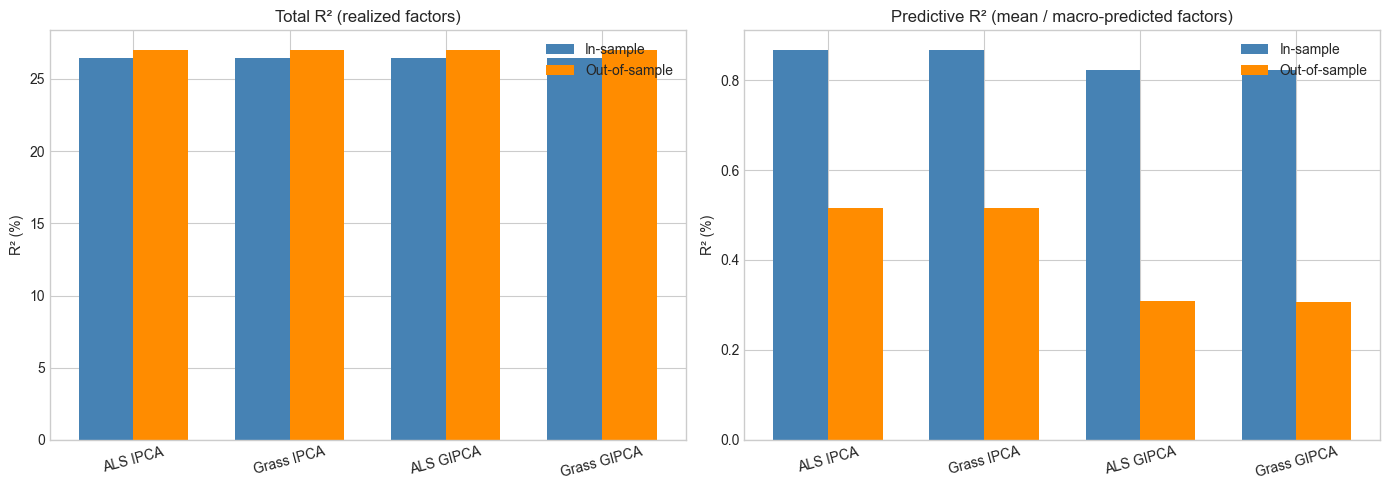

In [ ]:
sup2 = chr(178)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(models))
w = 0.35

is_tot = [results[m]['is_total'] * 100 for m in models]
oos_tot = [results[m]['oos_total'] * 100 for m in models]
axes[0].bar(x - w/2, is_tot, w, label='In-sample', color='steelblue')
axes[0].bar(x + w/2, oos_tot, w, label='Out-of-sample', color='darkorange')
axes[0].set_ylabel('R' + sup2 + ' (%)')
axes[0].set_title('Total R' + sup2 + ' (realized factors)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].set_ylim(bottom=0)

is_pred = [results[m]['is_pred'] * 100 for m in models]
oos_pred = [results[m]['oos_pred'] * 100 for m in models]
axes[1].bar(x - w/2, is_pred, w, label='In-sample', color='steelblue')
axes[1].bar(x + w/2, oos_pred, w, label='Out-of-sample', color='darkorange')
axes[1].set_ylabel('R' + sup2 + ' (%)')
axes[1].set_title('Predictive R' + sup2 + ' (mean / macro-predicted factors)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. Convergence Comparison

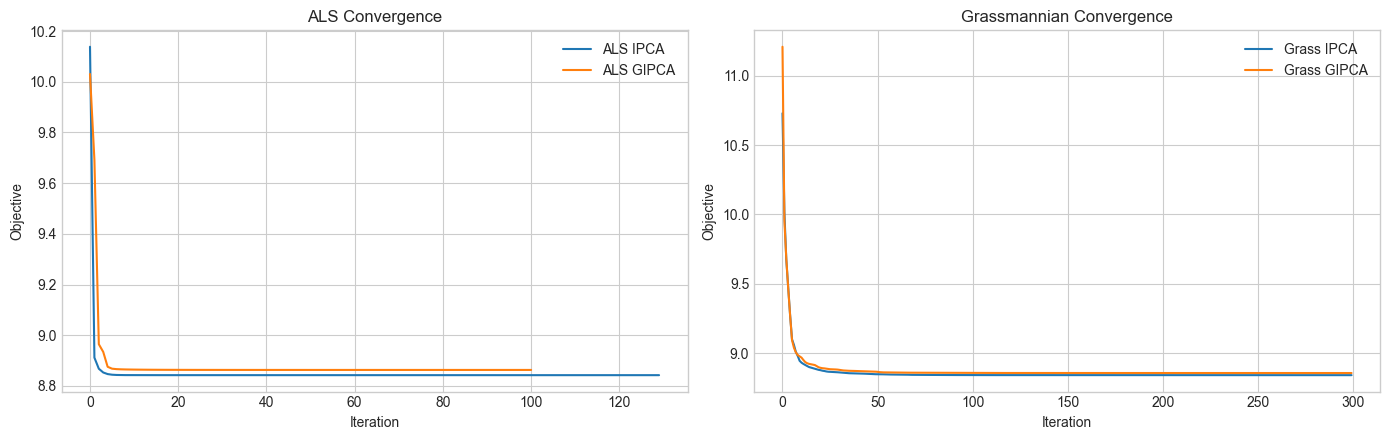

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(hist_als_ipca, label='ALS IPCA')
axes[0].plot(hist_als_gipca, label='ALS GIPCA')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Objective')
axes[0].set_title('ALS Convergence')
axes[0].legend()

axes[1].plot(hist_grass_ipca, label='Grass IPCA')
axes[1].plot(hist_grass_gipca, label='Grass GIPCA')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Objective')
axes[1].set_title('Grassmannian Convergence')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Gamma Comparison

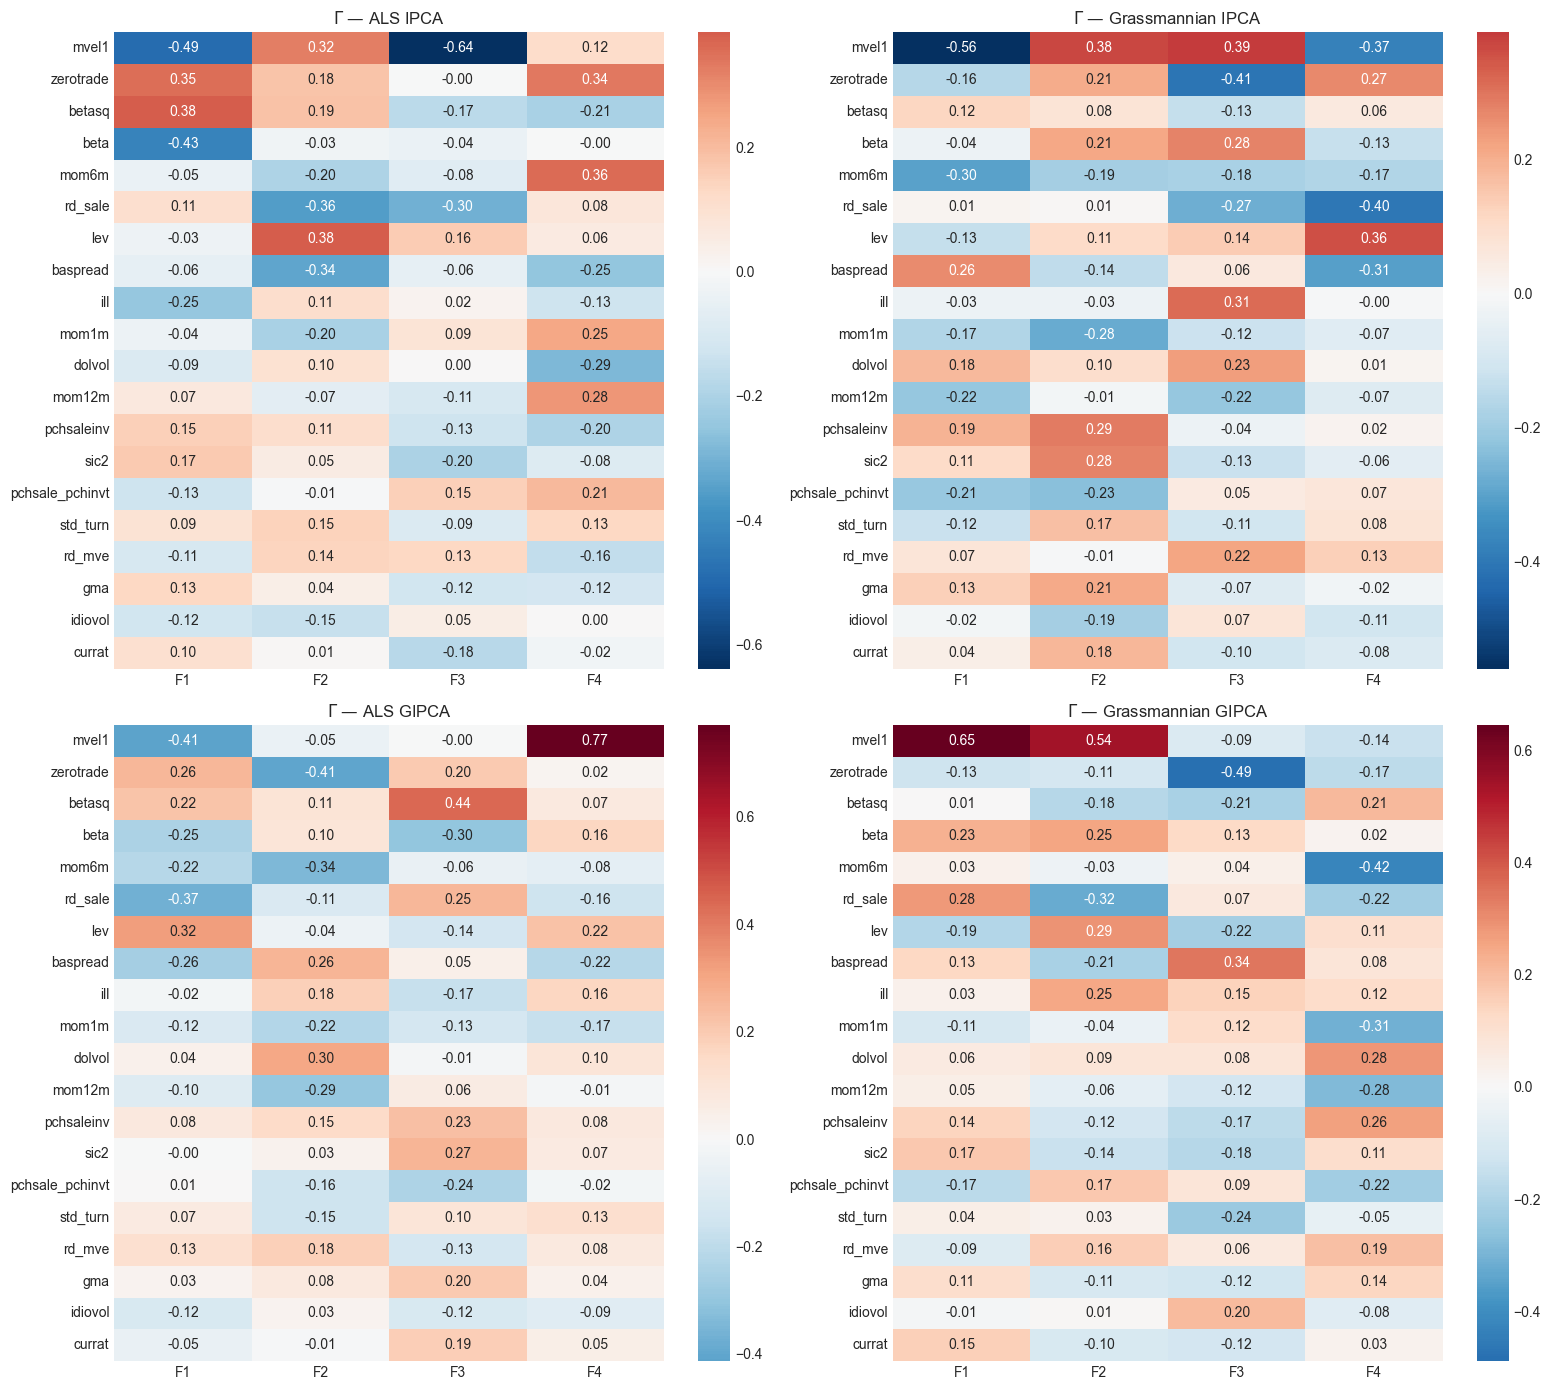

In [ ]:
max_load = np.maximum(
    np.maximum(np.max(np.abs(Gamma_als_ipca), axis=1),
               np.max(np.abs(Gamma_grass_ipca), axis=1)),
    np.maximum(np.max(np.abs(Gamma_als_gipca), axis=1),
               np.max(np.abs(Gamma_grass_gipca), axis=1)),
)
top_idx = np.argsort(max_load)[-20:][::-1]
top_names = [char_cols[i] for i in top_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
gammas = [
    (Gamma_als_ipca, 'ALS IPCA'),
    (Gamma_grass_ipca, 'Grassmannian IPCA'),
    (Gamma_als_gipca, 'ALS GIPCA'),
    (Gamma_grass_gipca, 'Grassmannian GIPCA'),
]

for ax, (G, title) in zip(axes.flat, gammas):
    df = pd.DataFrame(G[top_idx], index=top_names,
                      columns=[f'F{k+1}' for k in range(K)])
    sns.heatmap(df, cmap='RdBu_r', center=0, ax=ax, annot=True, fmt='.2f')
    ax.set_title(f'$\Gamma$ \u2014 {title}')

plt.tight_layout()
plt.show()

## 6. Delta (GIPCA Macro Loadings)

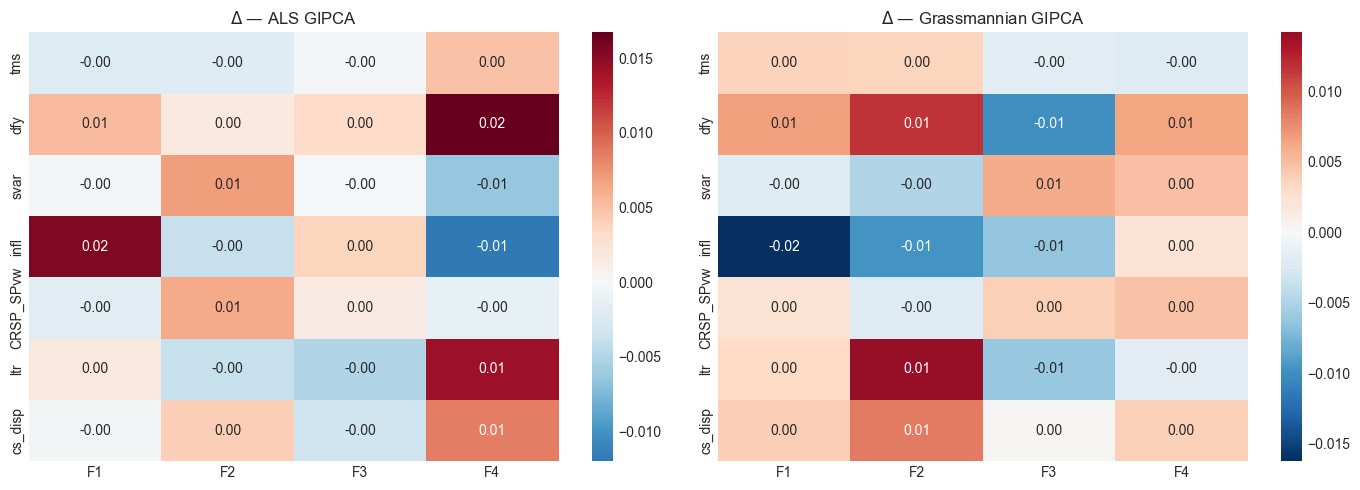

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (Delta, title) in zip(axes, [
    (Delta_als_gipca, 'ALS GIPCA'),
    (Delta_grass_gipca, 'Grassmannian GIPCA'),
]):
    df = pd.DataFrame(Delta.T, index=macro_cols_full,
                      columns=[f'F{k+1}' for k in range(K)])
    sns.heatmap(df, cmap='RdBu_r', center=0, ax=ax, annot=True, fmt='.2f')
    ax.set_title(f'$\Delta$ \u2014 {title}')

plt.tight_layout()
plt.show()

## 7. Factor Time Series

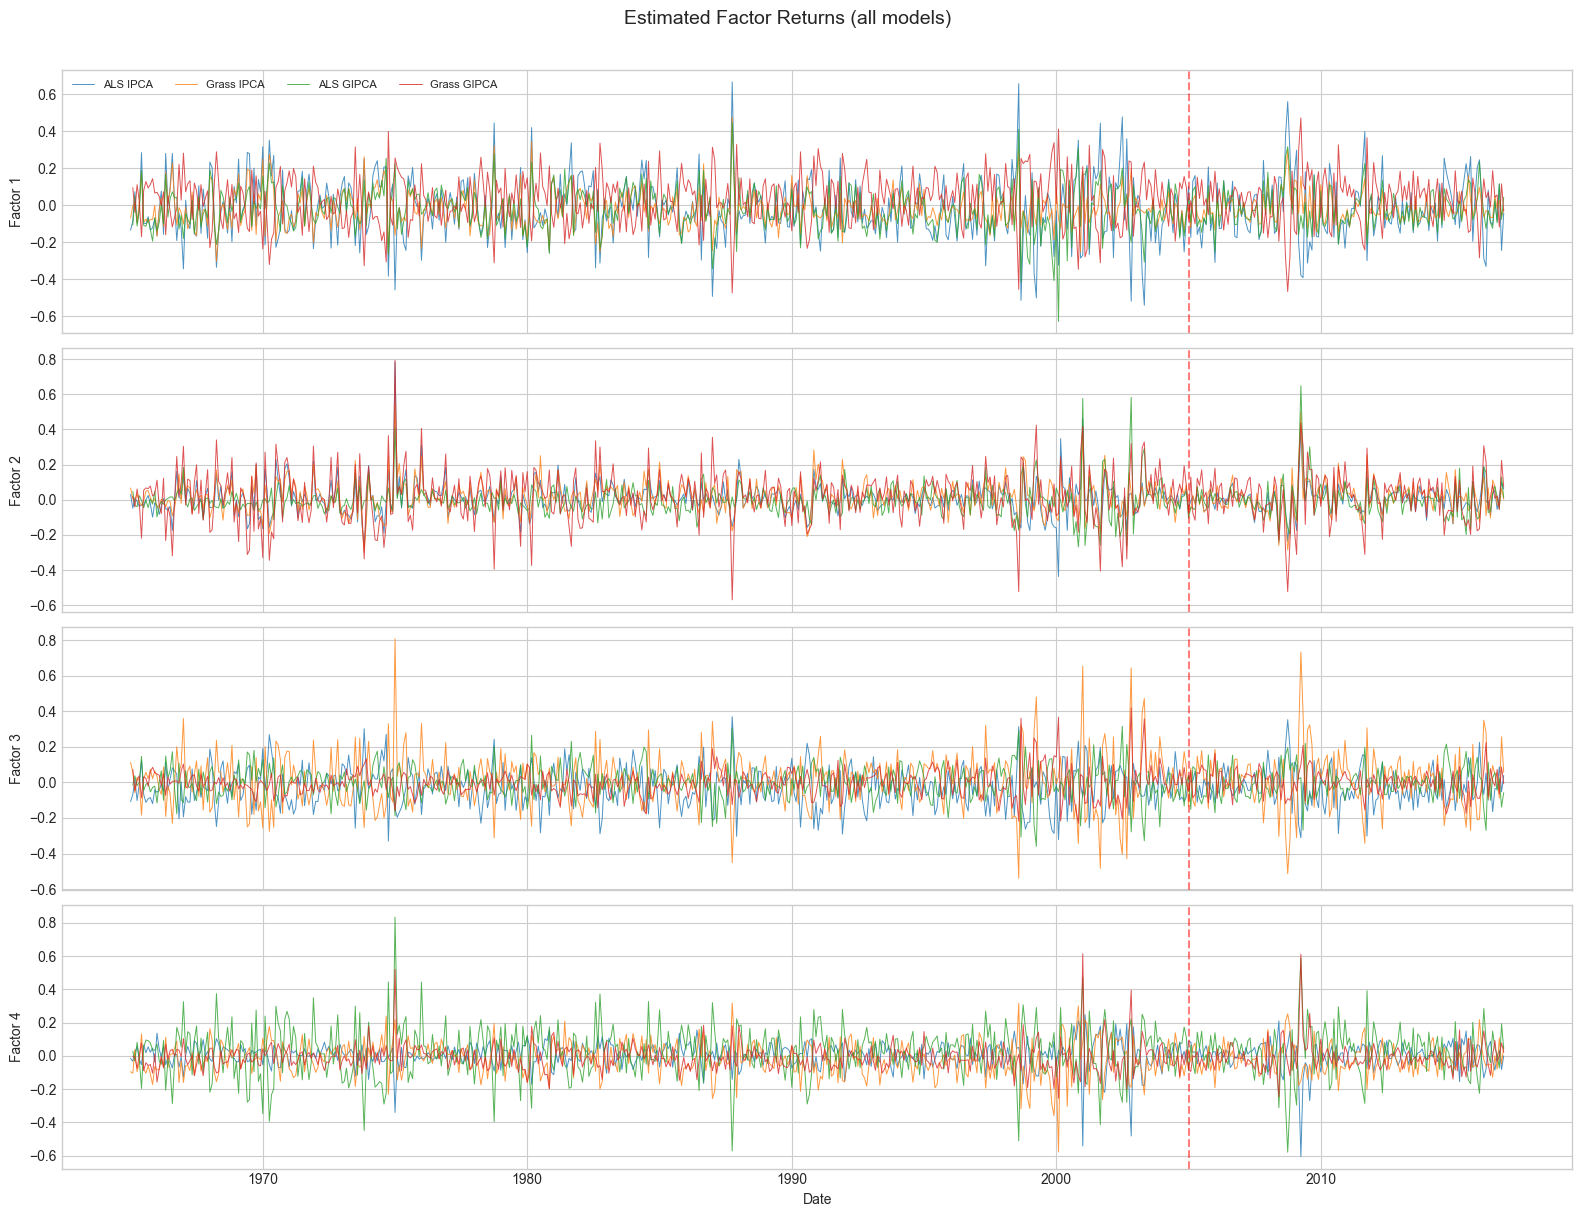

In [ ]:
all_f = {
    'ALS IPCA': np.vstack([f_als_ipca, f_oos_als_ipca]),
    'Grass IPCA': np.vstack([f_grass_ipca, f_oos_grass_ipca]),
    'ALS GIPCA': np.vstack([np.full((1, K), np.nan), f_als_gipca, f_oos_als_gipca]),
    'Grass GIPCA': np.vstack([np.full((1, K), np.nan), f_grass_gipca, f_oos_grass_gipca]),
}
all_dates = pd.to_datetime([str(m) for m in months], format='%Y%m')
model_colors = {'ALS IPCA': 'C0', 'Grass IPCA': 'C1',
                'ALS GIPCA': 'C2', 'Grass GIPCA': 'C3'}

fig, axes = plt.subplots(K, 1, figsize=(16, 3 * K), sharex=True)

for k in range(K):
    for m_name in models:
        axes[k].plot(all_dates, all_f[m_name][:, k], linewidth=0.7,
                     color=model_colors[m_name], label=m_name, alpha=0.8)
    axes[k].axvline(pd.Timestamp('2005-01-01'), color='red', ls='--', alpha=0.5)
    axes[k].set_ylabel(f'Factor {k+1}')
    if k == 0:
        axes[k].legend(fontsize=8, ncol=4)

axes[-1].set_xlabel('Date')
fig.suptitle('Estimated Factor Returns (all models)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 8. Portfolio Analysis (OOS)

In [ ]:
def quintile_analysis(rets_raw, Z, Gamma, signal_fn, label=""):
    T_e, N_e = rets_raw.shape
    n_q = 5
    q_rets = {q: [] for q in range(n_q)}
    for t in range(T_e):
        preds_t = signal_fn(t)
        rets_t = rets_raw[t]
        valid = ~np.isnan(rets_t)
        if valid.sum() < n_q:
            continue
        preds_v = preds_t[valid]
        rets_v = rets_t[valid]
        breaks = np.percentile(preds_v, np.linspace(0, 100, n_q + 1))
        for q in range(n_q):
            if q == n_q - 1:
                mask = (preds_v >= breaks[q]) & (preds_v <= breaks[q + 1])
            else:
                mask = (preds_v >= breaks[q]) & (preds_v < breaks[q + 1])
            if mask.sum() > 0:
                q_rets[q].append(np.mean(rets_v[mask]))
    avg = [np.mean(q_rets[q]) * 12 for q in range(n_q)]
    std = [np.std(q_rets[q]) * np.sqrt(12) for q in range(n_q)]
    sharpe = [avg[q] / std[q] if std[q] > 0 else 0 for q in range(n_q)]
    ls = np.array(q_rets[n_q - 1]) - np.array(q_rets[0])
    ls_avg = np.mean(ls) * 12
    ls_std = np.std(ls) * np.sqrt(12)
    ls_sr = ls_avg / ls_std if ls_std > 0 else 0
    return {'avg': avg, 'std': std, 'sharpe': sharpe,
            'ls_returns': ls, 'ls_avg': ls_avg, 'ls_std': ls_std, 'ls_sharpe': ls_sr}

pf_als_ipca = quintile_analysis(test_rets_raw, test_Z, Gamma_als_ipca,
    lambda t: test_Z[t] @ Gamma_als_ipca @ lam_als_ipca)
pf_grass_ipca = quintile_analysis(test_rets_raw, test_Z, Gamma_grass_ipca,
    lambda t: test_Z[t] @ Gamma_grass_ipca @ lam_grass_ipca)
pf_als_gipca = quintile_analysis(test_rets_raw, test_Z, Gamma_als_gipca,
    lambda t: test_Z[t] @ Gamma_als_gipca @ (Delta_als_gipca @ test_macro_lag[t]))
pf_grass_gipca = quintile_analysis(test_rets_raw, test_Z, Gamma_grass_gipca,
    lambda t: test_Z[t] @ Gamma_grass_gipca @ (Delta_grass_gipca @ test_macro_lag[t]))

pf_results = {
    'ALS IPCA': pf_als_ipca, 'Grass IPCA': pf_grass_ipca,
    'ALS GIPCA': pf_als_gipca, 'Grass GIPCA': pf_grass_gipca,
}
for m in models:
    results[m]['ls_sharpe'] = pf_results[m]['ls_sharpe']

print("Portfolio sorts use LAGGED macro for GIPCA (m_{t-1} predicts r_t)\n")
print(f"{'':12s}", end="")
for m in models:
    print(f"  {m:>16s}", end="")
print()
print(f"{'Quintile':12s}", end="")
for m in models:
    print(f"  {'Ret%':>7s} {'SR':>7s}", end="")
print()
print("-" * (12 + 18 * 4))
for q in range(5):
    print(f"Q{q+1:<11d}", end="")
    for m in models:
        print(f"  {pf_results[m]['avg'][q]*100:>6.2f}% {pf_results[m]['sharpe'][q]:>6.2f}", end="")
    print()
print("-" * (12 + 18 * 4))
print(f"{'L/S (Q5-Q1)':<12s}", end="")
for m in models:
    print(f"  {pf_results[m]['ls_avg']*100:>6.2f}% {pf_results[m]['ls_sharpe']:>6.2f}", end="")
print()

Portfolio sorts use LAGGED macro for GIPCA (m_{t-1} predicts r_t)

                      ALS IPCA        Grass IPCA         ALS GIPCA       Grass GIPCA
Quintile         Ret%      SR     Ret%      SR     Ret%      SR     Ret%      SR
------------------------------------------------------------------------------------
Q1             16.54%   0.77   16.54%   0.78   13.96%   0.87   13.97%   0.87
Q2             11.64%   0.68   11.70%   0.69   11.49%   0.72   11.44%   0.72
Q3             12.64%   0.72   12.57%   0.71   10.76%   0.62   10.89%   0.63
Q4             11.56%   0.61   11.59%   0.61   11.86%   0.57   11.70%   0.57
Q5             11.02%   0.53   11.00%   0.53   15.34%   0.59   15.39%   0.59
------------------------------------------------------------------------------------
L/S (Q5-Q1)    -5.52%  -0.41   -5.54%  -0.41    1.38%   0.08    1.42%   0.08


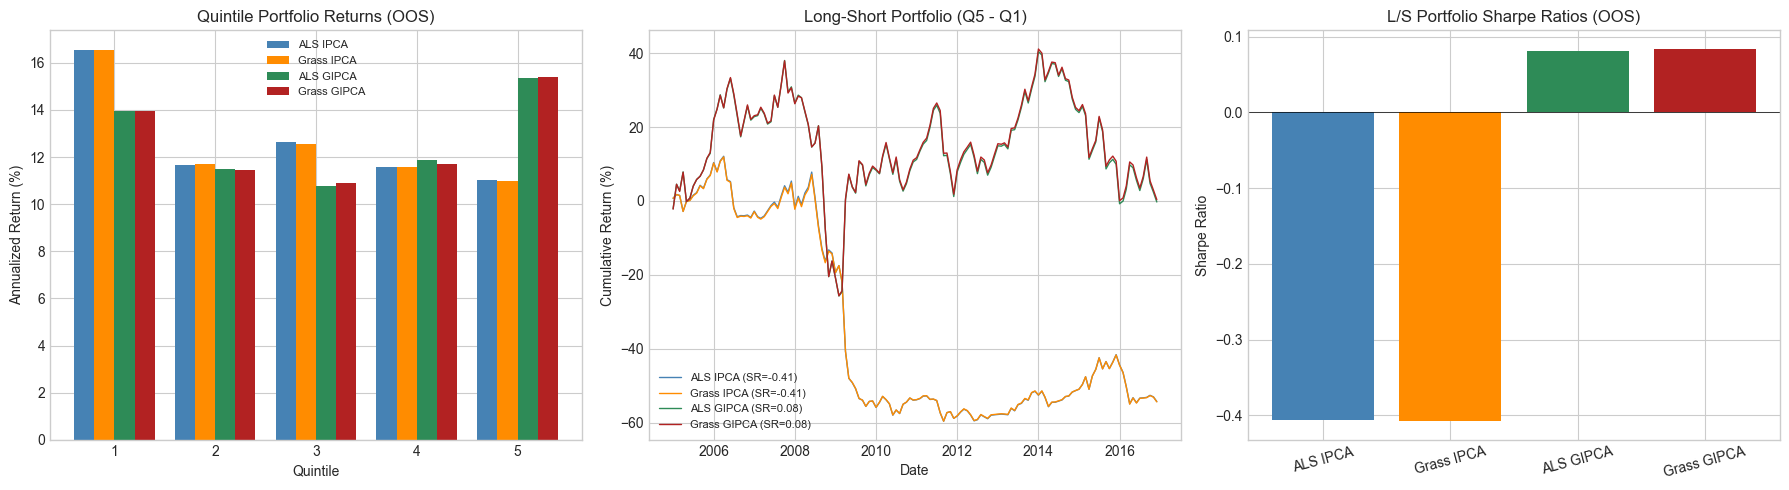

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

x = np.arange(5) + 1
n_m = len(models)
w = 0.8 / n_m
offsets = np.linspace(-(n_m - 1) * w / 2, (n_m - 1) * w / 2, n_m)

for i, m in enumerate(models):
    axes[0].bar(x + offsets[i], [r * 100 for r in pf_results[m]['avg']], w,
               label=m, color=colors[i])
axes[0].set_xlabel('Quintile')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Quintile Portfolio Returns (OOS)')
axes[0].set_xticks(x)
axes[0].legend(fontsize=8)

oos_dates = all_dates[split_idx:split_idx + len(pf_als_ipca['ls_returns'])]
for i, m in enumerate(models):
    cum = np.cumprod(1 + pf_results[m]['ls_returns']) - 1
    axes[1].plot(oos_dates, cum * 100, label=f"{m} (SR={pf_results[m]['ls_sharpe']:.2f})",
                color=colors[i], linewidth=1.0)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].set_title('Long-Short Portfolio (Q5 - Q1)')
axes[1].legend(fontsize=8)

ls_sharpes = [pf_results[m]['ls_sharpe'] for m in models]
axes[2].bar(range(len(models)), ls_sharpes, color=colors)
axes[2].set_xticks(range(len(models)))
axes[2].set_xticklabels(models, rotation=15)
axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_title('L/S Portfolio Sharpe Ratios (OOS)')
axes[2].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 9. Final Summary

In [ ]:
sup2 = chr(178)

summary_rows = [
    ('Final objective', [f"{results[m]['obj']:.4f}" for m in models]),
    ('IS Total R' + sup2 + ' (%)', [f"{results[m]['is_total']*100:.2f}" for m in models]),
    ('IS Predictive R' + sup2 + ' (%)', [f"{results[m]['is_pred']*100:.2f}" for m in models]),
    ('OOS Total R' + sup2 + ' (%)', [f"{results[m]['oos_total']*100:.2f}" for m in models]),
    ('OOS Predictive R' + sup2 + ' (%)', [f"{results[m]['oos_pred']*100:.2f}" for m in models]),
    ('L/S Sharpe (OOS)', [f"{results[m]['ls_sharpe']:.2f}" for m in models]),
    ('Iterations', [f"{results[m]['iters']}" for m in models]),
    ('Wall time (s)', [f"{results[m]['time']:.1f}" for m in models]),
    ('Parameters', [f"{results[m]['params']}" for m in models]),
    ('Predictive signal', ['mean(f)', 'mean(f)', "Delta' m_{t-1}", "Delta' m_{t-1}"]),
]

summary_df = pd.DataFrame(
    {row[0]: row[1] for row in summary_rows},
    index=models,
).T

print("\n" + "=" * 80)
print("       IPCA vs GIPCA (Welch-Goyal Macro): Final Comparison")
print("=" * 80)
print(summary_df.to_string())
print("=" * 80)
print("\nNotes:")
print(f"  - IPCA predictive R{sup2} uses mean factor (lambda = mean(f_t))")
print(f"  - GIPCA predictive R{sup2} uses LAGGED macro: E_t[f_{{t+1}}] = Delta' m_t")
print(f"  - GIPCA alpha = {ALPHA} (penalty on latent component f0)")
print(f"  - GIPCA has {K*R} extra parameters (K*R = {K}*{R}) for macro loadings")
print(f"  - Macro variables: {', '.join(macro_cols_full)}")
print(f"  - cs_disp = cross-sectional return dispersion (constructed from CRSP)")
print(f"  - Macro z-scored using training-period statistics only (no look-ahead)")
print(f"  - No contemporaneous look-ahead in predictive R{sup2} or portfolio sorts")


       IPCA vs GIPCA (Welch-Goyal Macro): Final Comparison
                      ALS IPCA Grass IPCA       ALS GIPCA     Grass GIPCA
Final objective         8.8424     8.8425          8.8630          8.8579
IS Total R² (%)          26.46      26.46           26.46           26.46
IS Predictive R² (%)      0.87       0.87            0.82            0.82
OOS Total R² (%)         27.00      27.01           27.00           27.01
OOS Predictive R² (%)     0.52       0.52            0.31            0.31
L/S Sharpe (OOS)         -0.41      -0.41            0.08            0.08
Iterations                 129        300             100             300
Wall time (s)            474.1      265.7           457.5           272.0
Parameters                 380        380             408             408
Predictive signal      mean(f)    mean(f)  Delta' m_{t-1}  Delta' m_{t-1}

Notes:
  - IPCA predictive R² uses mean factor (lambda = mean(f_t))
  - GIPCA predictive R² uses LAGGED macro: E_t[f_{t+1}] =